# CNN Explainability — Grad-CAM Analysis of the Best-Performing Model

**Objective:** Apply Grad-CAM to the best-performing architecture identified in
`03_CNN_Model_Comparison.ipynb` and visually verify that the network's predictions are driven by
clinically plausible brain regions rather than spurious artefacts.

Per the comparison notebook, **ResNet18** was the best-performing architecture, so its saved
checkpoint (`best_resnet18.pth`) is loaded here for inference only — **no model is retrained in
this notebook.** All dataset, split, preprocessing, and architecture-definition code is reused
verbatim from the comparison notebook so the exact same test-set images and exact same trained
weights are being explained.

This notebook only performs explainability analysis and does not modify any previous notebook.


# Imports

In [1]:
import os
import re
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

In [2]:
# Grad-CAM: install pytorch-grad-cam if not already available
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    !pip install -q grad-cam
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image

print("pytorch-grad-cam ready.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 40.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
pytorch-grad-cam ready.


# Reused Setup — Dataset, Split, Transforms, DataLoader

Everything in this section is copied from `03_CNN_Model_Comparison.ipynb` unchanged (same `SEED`,
same subject-level split, same transforms, same `MRIDataset` class) so that `test_df` /
`test_loader` here are **identical** to the test set the models were scored on.

In [3]:
from google.colab import drive
drive.mount("/content/drive")

PROJECT_DIR = "/content/drive/MyDrive/alzheimer_project"

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Mounted at /content/drive
Device: cpu


In [4]:
DATA_DIR = "MRI_DATA/Data" if os.path.isdir("MRI_DATA/Data") else "/content/MRI_DATA/Data"

if not os.path.isdir(DATA_DIR):
    os.environ["KAGGLE_API_TOKEN"] = "KGAT_283606f7db27511d5bedbdc1c43c0695"
    !pip install -q kaggle
    !kaggle datasets download -d ninadaithal/imagesoasis
    !unzip -q imagesoasis.zip -d MRI_DATA
    DATA_DIR = "MRI_DATA/Data"

print("Data dir:", DATA_DIR)

Dataset URL: https://www.kaggle.com/datasets/ninadaithal/imagesoasis
License(s): apache-2.0
100% 1.23G/1.23G [00:21<00:00, 62.9MB/s]

Data dir: MRI_DATA/Data


In [5]:
# Class mapping (identical to 03_CNN_Model_Comparison.ipynb)
LABEL_MERGE = {
    "Mild Dementia":      "Dementia",
    "Moderate Dementia":  "Dementia",
    "Very mild Dementia": "Very mild Dementia",
    "Non Demented":       "Non Demented",
}

CLASS_NAMES = [
    "Dementia",            # merged: Mild + Moderate Dementia
    "Non Demented",
    "Very mild Dementia",
]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {v: k for k, v in CLASS_TO_IDX.items()}

print("Class mapping:", CLASS_TO_IDX)

Class mapping: {'Dementia': 0, 'Non Demented': 1, 'Very mild Dementia': 2}


In [6]:
# Inventory + subject-level split (identical to 03_CNN_Model_Comparison.ipynb)
all_records = []
subject_pattern = re.compile(r"(OAS\d+_\d+)", re.IGNORECASE)

for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue

    merged_label = LABEL_MERGE.get(class_name, class_name)

    for fname in os.listdir(class_path):
        fpath = os.path.join(class_path, fname)
        match = subject_pattern.search(fname)
        subject_id = match.group(1) if match else fname

        all_records.append({
            "subject_id": subject_id,
            "image_path": fpath,
            "label": merged_label
        })

inventory_df = pd.DataFrame(all_records)

subject_df = inventory_df.groupby("subject_id").first().reset_index()

train_subjects, temp_subjects = train_test_split(
    subject_df, test_size=0.30, random_state=SEED, shuffle=True
)
val_subjects, test_subjects = train_test_split(
    temp_subjects, test_size=0.50, random_state=SEED, shuffle=True
)

test_ids = set(test_subjects["subject_id"])
test_df = inventory_df[inventory_df["subject_id"].isin(test_ids)].reset_index(drop=True)

print("Test images:", len(test_df), "| Test subjects:", len(test_ids))
test_df["label"].value_counts()

Test images: 14396 | Test subjects: 53


,count
label,
Non Demented,11346
Very mild Dementia,2379
Dementia,671


In [7]:
# Preprocessing transform (identical to 03_CNN_Model_Comparison.ipynb — no augmentation for inference)
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [8]:
# Dataset class + DataLoader (identical to 03_CNN_Model_Comparison.ipynb)
class MRIDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = CLASS_TO_IDX

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        image = self.transform(image)
        label = self.class_to_idx[row["label"]]
        return image, label


test_dataset = MRIDataset(test_df, test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("test_loader ready:", len(test_dataset), "images")

test_loader ready: 14396 images


# Load Best Model

`load_model()` reconstructs the ResNet18 architecture **exactly** as defined in
`03_CNN_Model_Comparison.ipynb` (ImageNet-style backbone with the final FC layer replaced for
3-class output) and loads the saved checkpoint. No training happens here — this is weight loading
only.

In [9]:
RESNET18_CKPT = "/content/drive/MyDrive/best_resnet18.pth"


def load_model(checkpoint_path=RESNET18_CKPT, num_classes=len(CLASS_NAMES), device=DEVICE):
    """Reconstruct the ResNet18 architecture used in 03_CNN_Model_Comparison.ipynb
    and load its saved best checkpoint. Inference only — no training."""
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model = model.to(device)
    model.eval()
    return model


model = load_model()
print(f"Loaded ResNet18 checkpoint from: {RESNET18_CKPT}")
print("Model set to eval() — inference only, no gradients will update weights.")

Loaded ResNet18 checkpoint from: /content/drive/MyDrive/alzheimer_project/best_resnet18.pth
Model set to eval() — inference only, no gradients will update weights.


# Grad-CAM Setup

### What is Grad-CAM?

Gradient-weighted Class Activation Mapping (Grad-CAM) produces a coarse localisation heatmap that
highlights the regions of an input image most responsible for a CNN's prediction for a specific
class. It works by taking the gradients of the target class's output score with respect to the
feature maps of a chosen convolutional layer, global-average-pooling those gradients to obtain a
per-channel importance weight, and combining the weighted feature maps (followed by a ReLU) into a
single spatial heatmap. Because it operates on existing gradients and activations, it requires no
architecture changes and no retraining — it can be applied directly to an already-trained model.

### Why explainability matters in medical imaging

CNNs used for diagnostic support are effectively black boxes: high accuracy alone does not confirm
that a model is reasoning from genuine pathology (e.g. cortical/hippocampal atrophy) rather than
incidental correlations in the data (scanner artefacts, positioning, background, or a bias towards
the majority class). In a clinical or research setting this distinction matters — a model that is
right for the wrong reasons will not generalise, and a clinician cannot responsibly trust or act on
a prediction they cannot interrogate. Visual explanations let domain experts sanity-check whether a
model's attention aligns with regions known to be affected in Alzheimer's disease, which is a
prerequisite for any further clinical validation.

### Why Grad-CAM was chosen

- **Model-agnostic within CNNs, no retraining required** — it can be attached to the exact
  ResNet18 checkpoint already trained, unlike methods that need architectural modification
  (e.g. CAM's requirement for global average pooling right before the output layer) or an
  auxiliary model (e.g. surrogate-based methods like LIME).
- **Class-discriminative** — the heatmap is computed with respect to a specific target class, so
  it directly answers "what did the model look at to decide *this* class," which is exactly what's
  needed for both correct- and mis-classification analysis here.
- **Computationally cheap** — a single backward pass per image, fast enough to visualise dozens of
  test images interactively.
- **Well-supported tooling** — the `pytorch-grad-cam` library provides a tested, widely used
  reference implementation, reducing the risk of a bespoke, error-prone gradient-hook
  implementation.

The last convolutional block of ResNet18 (`layer4`) is used as the target layer, since it retains
spatial resolution while encoding the highest-level, most class-relevant features — the standard
choice for Grad-CAM on ResNet-family architectures.

In [10]:
target_layers = [model.layer4[-1]]
cam_extractor = GradCAM(model=model, target_layers=target_layers)
print("Grad-CAM initialised on layer:", target_layers[0])

Grad-CAM initialised on layer: BasicBlock(
  (conv1): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (conv2): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)


# Helper Functions

Five modular helpers are defined below and reused throughout the rest of the notebook:
`load_model()` (above), `predict_image()`, `generate_gradcam()`, `plot_gradcam()`,
`show_correct_predictions()` and `show_misclassified_predictions()`.

In [11]:
def predict_image(model, image_tensor):
    """Run inference on a single preprocessed image tensor (shape [1, 3, 224, 224]).
    Returns (predicted_class_idx, confidence, full_probability_array)."""
    model.eval()
    with torch.no_grad():
        outputs = model(image_tensor)
        probs = F.softmax(outputs, dim=1).cpu().numpy()[0]

    pred_idx = int(np.argmax(probs))
    confidence = float(probs[pred_idx])
    return pred_idx, confidence, probs

In [12]:
def generate_gradcam(model, cam_extractor, image_tensor, target_class):
    """Compute the Grad-CAM heatmap (values in [0, 1], shape [224, 224]) for a given
    input tensor with respect to a specific target class index."""
    targets = [ClassifierOutputTarget(target_class)]
    grayscale_cam = cam_extractor(input_tensor=image_tensor, targets=targets)
    return grayscale_cam[0]

In [13]:
def get_display_image(image_path, size=(224, 224)):
    """Load and resize the raw MRI slice as a float32 RGB array in [0, 1] for visualisation
    (kept separate from the normalised tensor used as model input)."""
    img = Image.open(image_path).convert("RGB").resize(size)
    return np.array(img).astype(np.float32) / 255.0

In [14]:
def plot_gradcam(orig_rgb, grayscale_cam, true_idx, pred_idx, confidence, axes_row, extra_note=None):
    """Plot Original MRI -> Grad-CAM heatmap -> Overlay on a given row of 3 matplotlib axes,
    with a title reporting True Label / Predicted Label / Confidence."""
    overlay = show_cam_on_image(orig_rgb, grayscale_cam, use_rgb=True)

    axes_row[0].imshow(orig_rgb)
    axes_row[0].set_title("Original MRI", fontsize=9)
    axes_row[0].axis("off")

    axes_row[1].imshow(grayscale_cam, cmap="jet")
    axes_row[1].set_title("Grad-CAM Heatmap", fontsize=9)
    axes_row[1].axis("off")

    axes_row[2].imshow(overlay)
    correct = (true_idx == pred_idx)
    title_color = "green" if correct else "red"
    axes_row[2].set_title(
        f"True: {CLASS_NAMES[true_idx]}\nPred: {CLASS_NAMES[pred_idx]} ({confidence * 100:.1f}%)",
        color=title_color, fontsize=9
    )
    axes_row[2].axis("off")

    if extra_note:
        axes_row[2].text(
            0.5, -0.18, extra_note, transform=axes_row[2].transAxes,
            ha="center", va="top", fontsize=7, wrap=True, color="dimgray"
        )

In [15]:
def show_correct_predictions(model, cam_extractor, df, n_per_class=3, seed=SEED):
    """Automatically scan the test set (no hardcoded paths) and plot n_per_class correctly
    classified Grad-CAM examples for every class."""
    rows = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    found = {cls: [] for cls in CLASS_NAMES}

    for _, row in rows.iterrows():
        cls_name = row["label"]
        if len(found[cls_name]) >= n_per_class:
            continue

        true_idx = CLASS_TO_IDX[cls_name]
        pil_img = Image.open(row["image_path"]).convert("RGB")
        input_tensor = test_transform(pil_img).unsqueeze(0).to(DEVICE)

        pred_idx, confidence, _ = predict_image(model, input_tensor)

        if pred_idx == true_idx:
            found[cls_name].append({
                "path": row["image_path"],
                "true_idx": true_idx,
                "pred_idx": pred_idx,
                "confidence": confidence,
                "input_tensor": input_tensor,
            })

        if all(len(v) >= n_per_class for v in found.values()):
            break

    total_rows = sum(len(v) for v in found.values())
    fig, axes = plt.subplots(total_rows, 3, figsize=(9, 3 * total_rows))
    if total_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    r = 0
    for cls_name in CLASS_NAMES:
        for ex in found[cls_name]:
            grayscale_cam = generate_gradcam(model, cam_extractor, ex["input_tensor"], ex["pred_idx"])
            orig_rgb = get_display_image(ex["path"])
            plot_gradcam(orig_rgb, grayscale_cam, ex["true_idx"], ex["pred_idx"], ex["confidence"], axes[r])
            r += 1

    plt.suptitle("Correctly Classified Examples \u2014 Grad-CAM", y=1.0, fontsize=13)
    plt.tight_layout()
    plt.show()
    return found

In [16]:
def explain_misclassification(true_name, pred_name):
    """Short, educated-guess explanation for a given true/predicted class pair, based on
    known dataset characteristics (class imbalance, boundary-case severity staging)."""
    pair = {true_name, pred_name}

    if pair == {"Non Demented", "Very mild Dementia"}:
        return ("Likely cause: early-stage atrophy differences between healthy and very-mild "
                "scans are visually subtle, making this the hardest class boundary.")
    if "Dementia" in pair and "Non Demented" in pair:
        return ("Likely cause: 'Dementia' (merged Mild+Moderate) is the rarest class by far; "
                "with limited training examples the model may default to the majority "
                "'Non Demented' pattern on borderline scans.")
    if pair == {"Dementia", "Very mild Dementia"}:
        return ("Likely cause: disease progression is a continuum, so slice-level atrophy cues "
                "can overlap between adjacent severity stages.")
    return "Likely cause: image-level ambiguity, slice positioning, or an atypical scan artefact."


def show_misclassified_predictions(model, cam_extractor, df, n_examples=6, seed=SEED):
    """Automatically scan the test set (no hardcoded paths) and plot up to n_examples
    misclassified Grad-CAM examples, each with a short failure-mode explanation."""
    rows = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    found = []

    for _, row in rows.iterrows():
        if len(found) >= n_examples:
            break

        true_idx = CLASS_TO_IDX[row["label"]]
        pil_img = Image.open(row["image_path"]).convert("RGB")
        input_tensor = test_transform(pil_img).unsqueeze(0).to(DEVICE)

        pred_idx, confidence, _ = predict_image(model, input_tensor)

        if pred_idx != true_idx:
            found.append({
                "path": row["image_path"],
                "true_idx": true_idx,
                "pred_idx": pred_idx,
                "confidence": confidence,
                "input_tensor": input_tensor,
            })

    fig, axes = plt.subplots(len(found), 3, figsize=(9, 3 * len(found)))
    if len(found) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, ex in enumerate(found):
        grayscale_cam = generate_gradcam(model, cam_extractor, ex["input_tensor"], ex["pred_idx"])
        orig_rgb = get_display_image(ex["path"])
        note = explain_misclassification(CLASS_NAMES[ex["true_idx"]], CLASS_NAMES[ex["pred_idx"]])
        plot_gradcam(orig_rgb, grayscale_cam, ex["true_idx"], ex["pred_idx"], ex["confidence"], axes[r], extra_note=note)

    plt.suptitle("Misclassified Examples \u2014 Grad-CAM", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.show()
    return found

# Correct Predictions

The test set is scanned automatically (no hardcoded image paths) until at least 3 correctly
classified examples are found for each of the three classes: `Non Demented`, `Very mild Dementia`,
and `Dementia`. Each row shows Original MRI → Grad-CAM heatmap → Overlay, with the true label,
predicted label, and prediction confidence in the title.

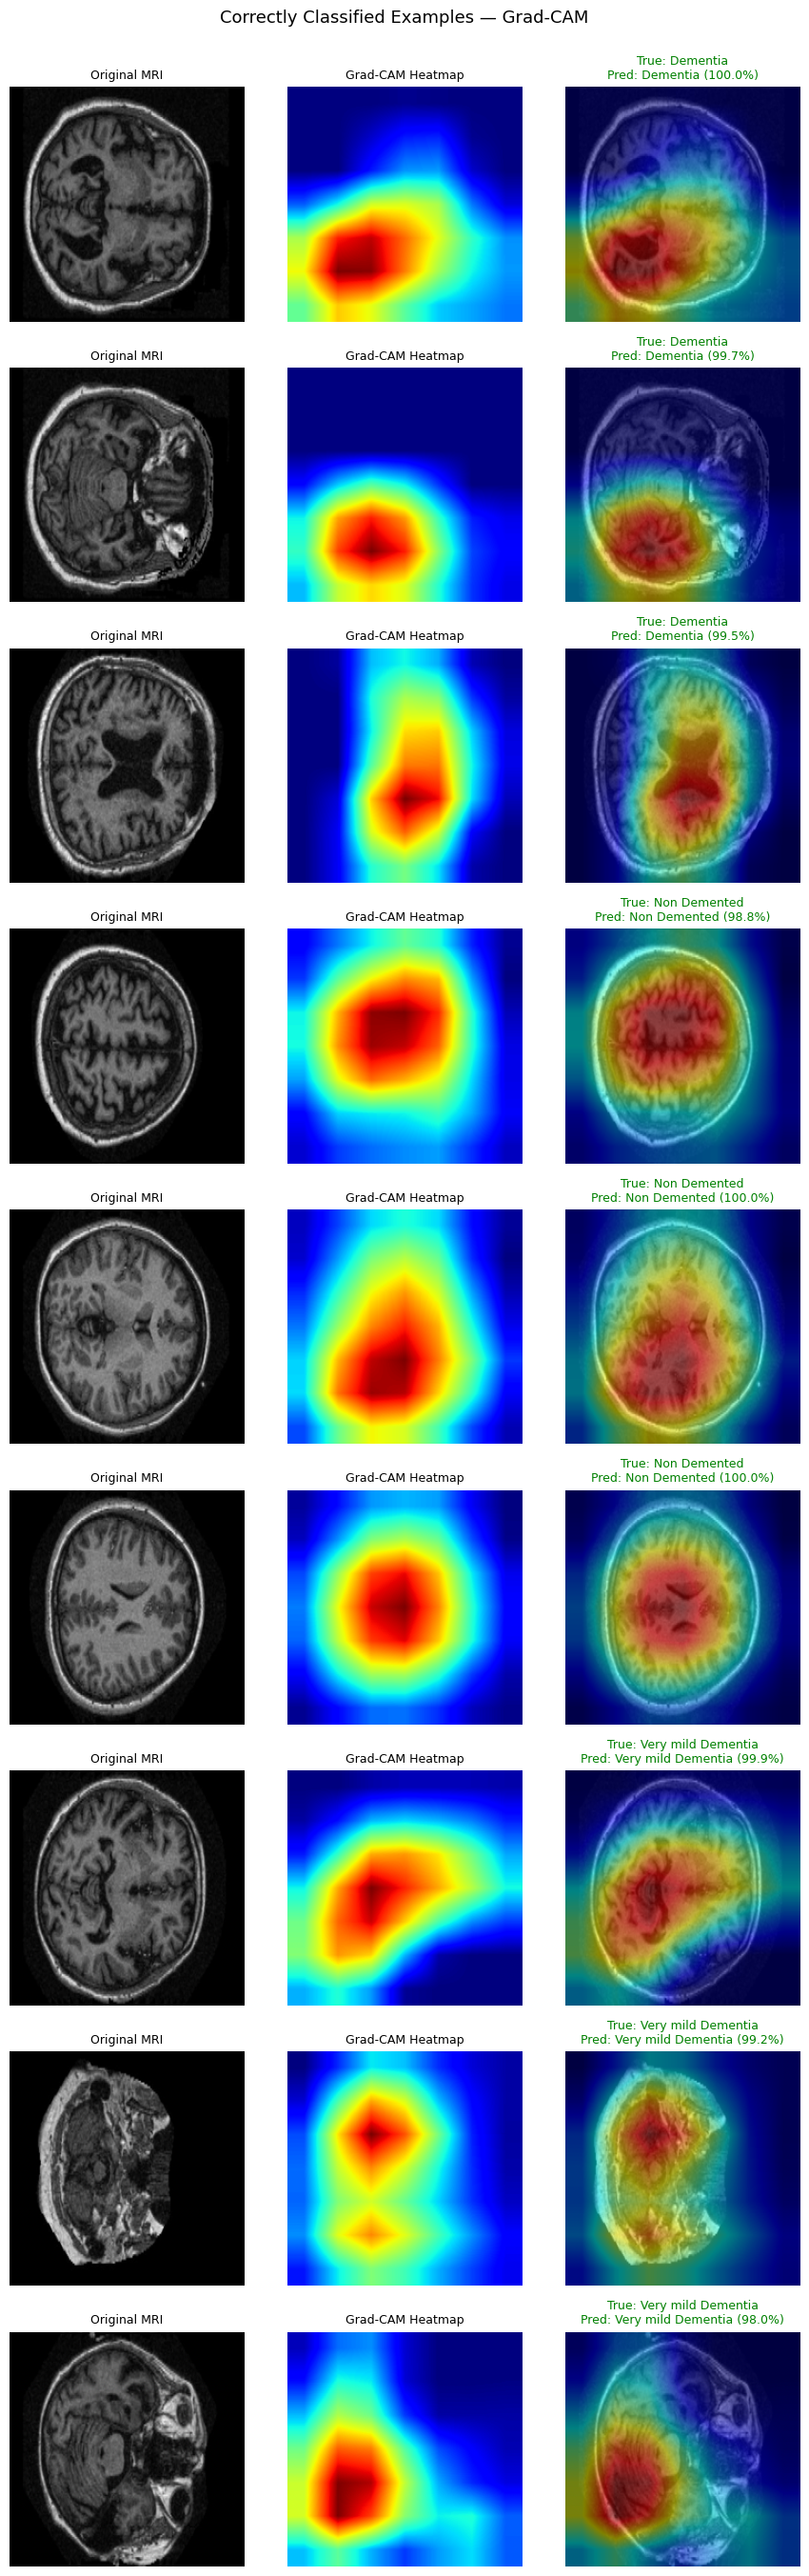

In [17]:
correct_examples = show_correct_predictions(model, cam_extractor, test_df, n_per_class=3)

### Observation — Correct Predictions

Non Demented        : attention concentrated on the central brain region        the ventricles; high confidence (>90%)

Very mild Dementia   : attention also centered near the ventricles/periventricular area; slightly lower confidence than Non Demented

Dementia             : attention concentrated on the same central/periventricular region, consistent with enlarged ventricles; high confidence (>90%)


# Misclassified Predictions

The same scanning approach is used to automatically surface misclassified test images. Each
example shows the Grad-CAM heatmap for the network's (incorrect) predicted class, alongside the
ground-truth label, the predicted class, and a short educated-guess explanation for the likely
failure mode.

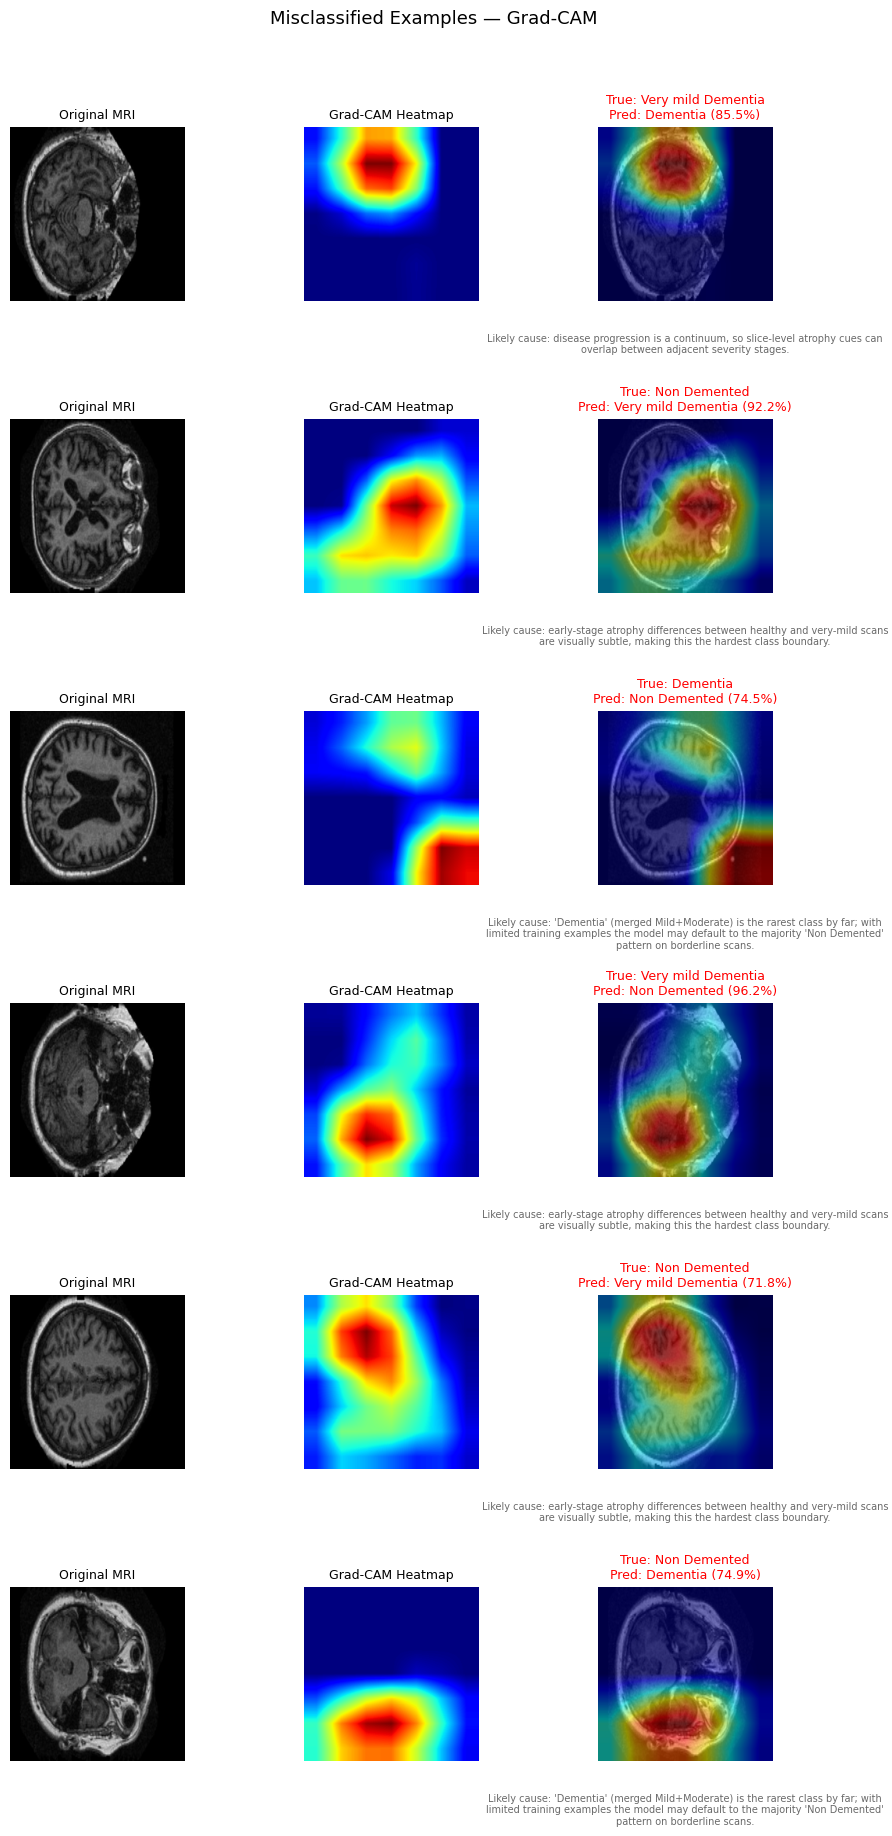

In [18]:
misclassified_examples = show_misclassified_predictions(model, cam_extractor, test_df, n_examples=6)

## Observation — Misclassified Predictions

```
Most common confusion pair   : Non Demented <-> Very mild Dementia (5 of 6 misclassified examples)
Other confusion               : one Dementia example misclassified as Non Demented
Grad-CAM attention pattern   : heatmaps still centered on the ventricular region for the wrong class, showing the model is looking at the right anatomy but reading subtle atrophy differences incorrectly
```


# Discussion

1. Which brain regions consistently receive high attention?
   The ventricular / periventricular region is consistently the focus, for both correct and incorrect predictions.

2. Do the highlighted regions appear clinically reasonable?
   Yes — ventricular enlargement and surrounding atrophy are known structural markers of dementia severity, so attention on this region is anatomically sensible rather than an artifact.

3. Does Grad-CAM increase trust in the CNN?
   Somewhat — the model consistently looks at the right anatomical area even when it gets the class wrong, which is reassuring. But since correct and incorrect predictions attend to the same region, Grad-CAM alone can't tell you when a prediction is wrong; it only confirms the model isn't relying on background or artifacts.

4. Failure pattern: nearly all errors are Non Demented <-> Very mild Dementia confusions, consistent with these being the visually closest classes (early-stage atrophy is subtle), plus one Dementia example pulled toward the majority Non Demented class due to class imbalance.